# Single-cell pseudobulk differential expression with pylimma (Kang 2018 PBMC)

AnnData-native walk-through of a pseudobulk `limma`/voom workflow on
the Kang 2018 PBMC IFN-beta stimulation dataset. The workflow:
aggregate counts per (donor, condition, cell_type), run pylimma's
standard pipeline per cell type, extract IFN-beta response contrasts.

**Dataset**: Kang HM *et al.* (2018). *Nat Biotechnol* 36:89-94.
Multiplexed droplet single-cell RNA-seq of PBMCs from 8 lupus
patients, with and without IFN-beta stimulation. ~25k cells x ~16k
genes across 8 annotated immune cell types.

**Why pseudobulk in one line**: when the experimental unit is a donor
rather than a cell, cell-level DE tests treat every cell as
independent and inflate their test statistics. Pseudobulking per
(donor, cell type) restores the correct sample size. Squair et al.
2021 (*Nat Commun* 12:5692) and Crowell et al. 2020 (*Nat Commun*
11:6077) are the canonical references; pseudobulk + limma/voom is in
the top tier of both benchmarks.

## Pipeline

1. Load the real Kang AnnData (pertpy preferred, figshare fallback)
2. tSNE visualisation (uses the pre-computed embedding)
3. Pseudobulk per (donor, condition, cell_type)
4. pylimma per cell type: `voom` -> `lm_fit` -> `contrasts_fit` ->
   `e_bayes` -> `top_table`
5. Top IFN-beta response genes per cell type


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
import pylimma

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 1. Load the Kang 2018 AnnData

Preferred loader: `pertpy.data.kang_2018()`. It tracks the
canonical Kang object and re-pins the source URL as needed
(scverse-maintained).

Fallback: `scanpy.read(..., backup_url=...)` against the figshare
mirror of the processed dataset used in the
[Heumos et al. 2023 Single-Cell Best Practices](https://www.sc-best-practices.org/)
book. `scanpy.read` caches the file locally after the first
download, so re-runs are network-free.

If the figshare URL ever 404s, the raw data lives at NCBI GEO
([GSE96583](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583))
and `pertpy` is the scverse-maintained fallback for the processed
object.

In [2]:
kang_cache = Path.cwd() / 'kang_2018.h5ad'
try:
    import pertpy as pt
    adata = pt.data.kang_2018()
    print('loaded via pertpy.data.kang_2018()')
except ImportError:
    adata = sc.read(
        kang_cache,
        backup_url='https://ndownloader.figshare.com/files/34464122',
    )
    print(f'loaded via figshare mirror -> {kang_cache}')

# Processed Kang uses `label` for condition and `replicate` for donor;
# normalise to pylimma-friendly names.
adata.obs = adata.obs.rename(columns={'label': 'condition',
                                       'replicate': 'donor'})

print(f'\nAnnData shape: {adata.shape}  (cells x genes)')
print(f'conditions: {sorted(adata.obs["condition"].unique())}')
print(f'donors ({adata.obs["donor"].nunique()}): '
      f'{sorted(adata.obs["donor"].unique())}')
print(f'cell types ({adata.obs["cell_type"].nunique()}):')
print(adata.obs['cell_type'].value_counts())

loaded via figshare mirror -> /Users/John/Documents/Projects/staged/pylimma/pylimma/examples/kang_pbmc/kang_2018.h5ad

AnnData shape: (24673, 15706)  (cells x genes)
conditions: ['ctrl', 'stim']
donors (8): ['patient_101', 'patient_1015', 'patient_1016', 'patient_1039', 'patient_107', 'patient_1244', 'patient_1256', 'patient_1488']
cell types (8):
cell_type
CD4 T cells          11238
CD14+ Monocytes       5697
B cells               2651
NK cells              1716
CD8 T cells           1621
FCGR3A+ Monocytes     1089
Dendritic cells        529
Megakaryocytes         132
Name: count, dtype: int64


## 2. tSNE visualisation

The processed AnnData carries pre-computed `tsne1` / `tsne2`
coordinates (from the original Seurat workflow the Kang paper
used), so plotting is cheap.

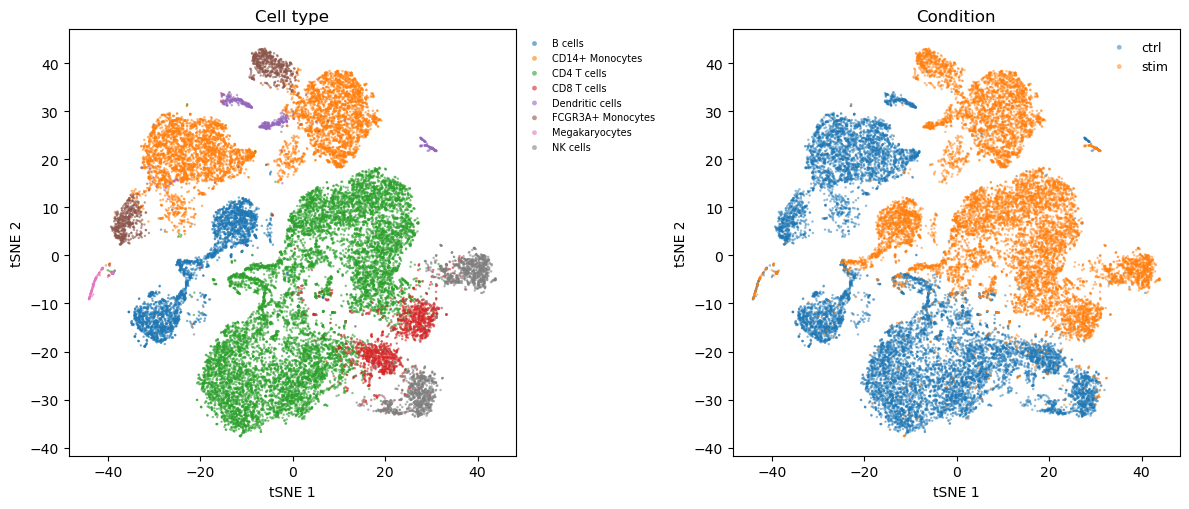

In [3]:
fig, (axCt, axCond) = plt.subplots(1, 2, figsize=(12, 5.2))

palette = plt.get_cmap('tab10').colors
cell_types = sorted(adata.obs['cell_type'].unique())
for k, ct in enumerate(cell_types):
    m = (adata.obs['cell_type'] == ct).values
    axCt.scatter(adata.obs.loc[m, 'tsne1'],
                 adata.obs.loc[m, 'tsne2'],
                 s=3, color=palette[k % len(palette)],
                 label=ct, edgecolor='none', alpha=0.6)
axCt.legend(fontsize=7, frameon=False, markerscale=2,
            bbox_to_anchor=(1.0, 1.0))
axCt.set_xlabel('tSNE 1'); axCt.set_ylabel('tSNE 2')
axCt.set_title('Cell type')

conditions = sorted(adata.obs['condition'].unique())
for k, cond in enumerate(conditions):
    m = (adata.obs['condition'] == cond).values
    axCond.scatter(adata.obs.loc[m, 'tsne1'],
                   adata.obs.loc[m, 'tsne2'],
                   s=3, color=palette[k], label=cond,
                   edgecolor='none', alpha=0.5)
axCond.legend(fontsize=9, frameon=False, markerscale=2)
axCond.set_xlabel('tSNE 1'); axCond.set_ylabel('tSNE 2')
axCond.set_title('Condition')

fig.tight_layout()
plt.show()

## 3. Pseudobulk

Sum raw counts per (donor, condition, cell_type) to produce one
row per biological replicate. Uses a pandas groupby on `adata.X` - transparent and
dependency-light. `decoupler.get_pseudobulk` is the scverse-
standard equivalent if you prefer it.
Keep replicates with at least 10 cells and 1,000 total counts to
avoid noise-dominated rows.

In [4]:
# Build a composite sample key and groupby directly.
keys = (adata.obs['donor'].astype(str) + '|' +
        adata.obs['condition'].astype(str) + '|' +
        adata.obs['cell_type'].astype(str)).values

# Row sums per group via pandas; handles sparse X via .dot with a
# one-hot indicator matrix (fast, memory-light).
uniq = pd.Index(pd.unique(keys))
onehot = np.zeros((adata.n_obs, len(uniq)), dtype=np.float32)
for i, k in enumerate(uniq):
    onehot[keys == k, i] = 1.0

X = adata.X
psbulk = (X.T @ onehot).T if hasattr(X, 'dot') else onehot.T @ X
psbulk = np.asarray(psbulk)   # (n_pseudobulk, n_genes)

n_cells = onehot.sum(axis=0)                # cells per pseudobulk sample
n_counts = psbulk.sum(axis=1)               # total counts per pseudobulk sample
keep = (n_cells >= 10) & (n_counts >= 1000)
psbulk = psbulk[keep]
uniq   = uniq[keep]

pb_parts = pd.Series(uniq).str.split('|', expand=True)
pb_obs = pd.DataFrame({
    'donor':     pb_parts[0].values,
    'condition': pb_parts[1].values,
    'cell_type': pb_parts[2].values,
}, index=uniq)

pb = ad.AnnData(X=psbulk, obs=pb_obs, var=adata.var.copy())

print(f'Pseudobulk AnnData shape: {pb.shape}  (samples x genes)')
print(f'\nsamples per cell type (ctrl + stim):')
print(pb.obs.groupby('cell_type', observed=True).size()
            .sort_values(ascending=False))

Pseudobulk AnnData shape: (112, 15706)  (samples x genes)

samples per cell type (ctrl + stim):
cell_type
B cells              16
CD14+ Monocytes      16
CD4 T cells          16
Dendritic cells      16
FCGR3A+ Monocytes    16
NK cells             16
CD8 T cells          14
Megakaryocytes        2
dtype: int64


## 4. Pseudobulk DE with pylimma (per cell type)

For each cell type, fit the full pipeline on the subset of
pseudobulk samples belonging to that cell type. The design has
intercept + stim indicator; the contrast tests stim - ctrl.

In [5]:
per_ct_results = {}
for ct in sorted(pb.obs['cell_type'].unique()):
    pb_ct = pb[(pb.obs['cell_type'] == ct).values].copy()
    # Skip cell types with too few replicates (e.g. Megakaryocytes in
    # Kang are rare enough that some cases lose one or both conditions).
    if pb_ct.obs['condition'].nunique() < 2 or pb_ct.shape[0] < 4:
        print(f'{ct:20s}: skipped ({pb_ct.shape[0]} samples)')
        continue

    # Design: intercept + stim indicator. Contrast = stim effect.
    design = np.column_stack([
        np.ones(pb_ct.shape[0]),
        (pb_ct.obs['condition'] == 'stim').astype(float).values,
    ])
    C = np.array([[0.0], [1.0]])

    # Fully AnnData-native pipeline. pylimma handles orientation and
    # the voom -> lm_fit weights handshake internally.
    pylimma.voom(pb_ct, design=design)
    pylimma.lm_fit(pb_ct, design=design, layer='voom_E')
    pylimma.contrasts_fit(pb_ct, contrasts=C)
    pylimma.e_bayes(pb_ct)
    tt = pylimma.top_table(pb_ct, coef=0, number=np.inf, sort_by='p')

    per_ct_results[ct] = tt
    n_sig = (tt['adj_p_value'] < 0.05).sum()
    print(f'{ct:20s}: {n_sig:5,} genes at adj_p_value < 0.05 '
          f'({pb_ct.shape[0]} pseudobulk samples)')


B cells             :   836 genes at adj_p_value < 0.05 (16 pseudobulk samples)
CD14+ Monocytes     : 5,079 genes at adj_p_value < 0.05 (16 pseudobulk samples)
CD4 T cells         : 1,162 genes at adj_p_value < 0.05 (16 pseudobulk samples)
CD8 T cells         :   177 genes at adj_p_value < 0.05 (14 pseudobulk samples)
Dendritic cells     : 1,105 genes at adj_p_value < 0.05 (16 pseudobulk samples)
FCGR3A+ Monocytes   : 1,263 genes at adj_p_value < 0.05 (16 pseudobulk samples)
Megakaryocytes      : skipped (2 samples)
NK cells            :   493 genes at adj_p_value < 0.05 (16 pseudobulk samples)


## 5. Top IFN-stimulated genes per cell type

Check the top hits. The canonical IFN response signature includes
ISG15, IFI6, IFIT1, IFIT3, IFI44L, MX1, OAS1, OAS3, STAT1, IRF7
- these should appear near the top of every cell type's table,
with larger logFC in myeloid populations (CD14+ Monocytes, DCs)
than in lymphocytes, reproducing Kang's published finding.

In [6]:
for ct, tt in per_ct_results.items():
    top5 = tt.head(5)[['log_fc', 'ave_expr', 'p_value', 'adj_p_value']]
    top5.index.name = f'top5 in {ct}'
    print(top5.round(3))
    print()

                 log_fc  ave_expr  p_value  adj_p_value
top5 in B cells                                        
ISG20             3.176    11.333      0.0          0.0
B2M               0.645    15.097      0.0          0.0
ISG15             5.520    10.242      0.0          0.0
LY6E              4.093     8.821      0.0          0.0
RPL10            -0.498    13.210      0.0          0.0

                         log_fc  ave_expr  p_value  adj_p_value
top5 in CD14+ Monocytes                                        
ISG20                     5.279    10.232      0.0          0.0
IL1RN                     6.177     7.938      0.0          0.0
IFITM2                    4.322     7.986      0.0          0.0
IFIT3                     7.196     8.372      0.0          0.0
CCL8                      9.182     9.335      0.0          0.0

                     log_fc  ave_expr  p_value  adj_p_value
top5 in CD4 T cells                                        
ISG20                 2.955    10.427 

## References

- Kang HM *et al.* (2018). *Nat Biotechnol* 36:89-94.
- Squair JW *et al.* (2021). *Nat Commun* 12:5692.
- Crowell HL *et al.* (2020). *Nat Commun* 11:6077.
- Murphy AE, Skene NG (2022). *Nat Commun* 13:7851.
